In [692]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



In [693]:
df = pd.read_csv('Salary_dataset.csv',index_col=0)
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [694]:
X = df['YearsExperience'].values.reshape(-1,1)
y = df['Salary'].values.reshape(-1,1)

In [695]:
y

array([[ 39344.],
       [ 46206.],
       [ 37732.],
       [ 43526.],
       [ 39892.],
       [ 56643.],
       [ 60151.],
       [ 54446.],
       [ 64446.],
       [ 57190.],
       [ 63219.],
       [ 55795.],
       [ 56958.],
       [ 57082.],
       [ 61112.],
       [ 67939.],
       [ 66030.],
       [ 83089.],
       [ 81364.],
       [ 93941.],
       [ 91739.],
       [ 98274.],
       [101303.],
       [113813.],
       [109432.],
       [105583.],
       [116970.],
       [112636.],
       [122392.],
       [121873.]])

In [696]:
X_train , X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [697]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [698]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [699]:
scaler2 = StandardScaler()
y_train = scaler2.fit_transform(y_train)
y_test = scaler2.transform(y_test)

In [700]:
class UnivariateLinearRegressor:
    def __init__(self,epochs,lr):
        self.epochs = epochs
        self.lr = lr
        self.w = 0
        self.b = 0
        self.loss_history = []

    def fit(self,x,y):
        n = len(x)
        for epoch in range(self.epochs):
            y_pred = self.w * x + self.b
            loss = np.mean((y-y_pred)**2)
            self.loss_history.append(loss)
            dw = (-2/n) * np.sum((y-y_pred)* x) 
            db = (-2/n) * np.sum(y-y_pred)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            print(f"Iteration {epoch+1}: MSE Loss ={loss}")
        

    def predict(self,x):
        return self.w * x +self.b
    
    def get_loss_history(self):
        return self.loss_history
        

In [701]:
model1 = UnivariateLinearRegressor(lr = 0.001 , epochs = 1500)
model1.fit(X_train,y_train)

Iteration 1: MSE Loss =1.0
Iteration 2: MSE Loss =0.996145697531262
Iteration 3: MSE Loss =0.9923067968551892
Iteration 4: MSE Loss =0.988483236426218
Iteration 5: MSE Loss =0.9846749549447211
Iteration 6: MSE Loss =0.9808818913560241
Iteration 7: MSE Loss =0.9771039848494274
Iteration 8: MSE Loss =0.9733411748572313
Iteration 9: MSE Loss =0.9695934010537638
Iteration 10: MSE Loss =0.9658606033544151
Iteration 11: MSE Loss =0.962142721914673
Iteration 12: MSE Loss =0.9584396971291641
Iteration 13: MSE Loss =0.9547514696306979
Iteration 14: MSE Loss =0.9510779802893158
Iteration 15: MSE Loss =0.9474191702113419
Iteration 16: MSE Loss =0.9437749807384396
Iteration 17: MSE Loss =0.9401453534466708
Iteration 18: MSE Loss =0.9365302301455601
Iteration 19: MSE Loss =0.9329295528771605
Iteration 20: MSE Loss =0.9293432639151252
Iteration 21: MSE Loss =0.9257713057637827
Iteration 22: MSE Loss =0.9222136211572126
Iteration 23: MSE Loss =0.9186701530583306
Iteration 24: MSE Loss =0.915140844657

In [702]:
loss_history = model1.get_loss_history()
loss_history

[np.float64(1.0),
 np.float64(0.996145697531262),
 np.float64(0.9923067968551892),
 np.float64(0.988483236426218),
 np.float64(0.9846749549447211),
 np.float64(0.9808818913560241),
 np.float64(0.9771039848494274),
 np.float64(0.9733411748572313),
 np.float64(0.9695934010537638),
 np.float64(0.9658606033544151),
 np.float64(0.962142721914673),
 np.float64(0.9584396971291641),
 np.float64(0.9547514696306979),
 np.float64(0.9510779802893158),
 np.float64(0.9474191702113419),
 np.float64(0.9437749807384396),
 np.float64(0.9401453534466708),
 np.float64(0.9365302301455601),
 np.float64(0.9329295528771605),
 np.float64(0.9293432639151252),
 np.float64(0.9257713057637827),
 np.float64(0.9222136211572126),
 np.float64(0.9186701530583306),
 np.float64(0.9151408446579716),
 np.float64(0.9116256393739803),
 np.float64(0.9081244808503041),
 np.float64(0.9046373129560884),
 np.float64(0.901164079784778),
 np.float64(0.8977047256532201),
 np.float64(0.8942591951007719),
 np.float64(0.890827432888411

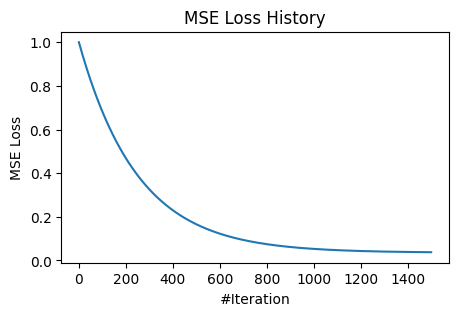

In [703]:

plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [704]:
def regression_metrics(y_true, y_pred):
    n = len(y_true)
    
    # 1. Mean Absolute Error (MAE)
    mae = np.mean(np.abs(y_true - y_pred))

    # 2. Mean Squared Error (MSE)
    mse = np.mean((y_true - y_pred) ** 2)

    # 3. Root Mean Squared Error (RMSE)
    rmse = np.sqrt(mse)

    # 4. Mean Absolute Percentage Error (MAPE)
    # Add small value to avoid division by zero
    epsilon = 1e-10
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

    # 5. R² Score
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_total)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "R²": r2
    }

In [705]:
y_pred1 = model1.predict(X_test)
y_pred1.shape

(6, 1)

In [706]:
regression_metrics(y_test,y_pred1)

{'MAE': np.float64(0.22316001241187214),
 'MSE': np.float64(0.06857225503782934),
 'RMSE': np.float64(0.26186304633878627),
 'MAPE': np.float64(47.72510058069785),
 'R²': np.float64(0.8973947623712942)}

In [707]:
from sklearn.metrics import mean_squared_error,r2_score
print("MSE",mean_squared_error(y_test,y_pred1))

MSE 0.06857225503782934


In [708]:
r2 = r2_score(y_test, y_pred1)
r2

0.8973947623712942

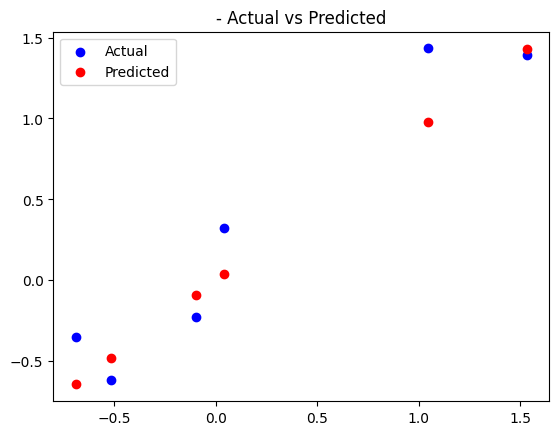

In [709]:
# Plot the results
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred1, color='red', label='Predicted')
plt.legend()
plt.title("- Actual vs Predicted")
plt.show()

using LinearRegression from sklearn

In [710]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train, y_train)



LinearRegression()

In [711]:
y_pred2 = model2.predict(X_test)
y_pred2.shape

(6, 1)

In [712]:
r2 = r2_score(y_test, y_pred2)
r2

0.9024461774180499

In [722]:
regression_metrics(y_test,y_pred2)

{'MAE': np.float64(0.22739005205192742),
 'MSE': np.float64(0.06519633652827414),
 'RMSE': np.float64(0.25533573296402157),
 'MAPE': np.float64(48.47678729181913),
 'R²': np.float64(0.9024461774180499)}

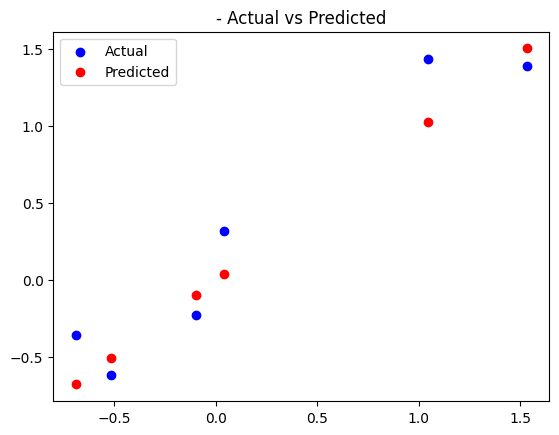

In [713]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred2, color='red', label='Predicted')
plt.legend()
plt.title("- Actual vs Predicted")
plt.show()

In [714]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor()
sgd.fit(X_train,y_train)
y_pred3 = sgd.predict(X_test)
r2 = r2_score(y_test, y_pred3)
r2

c:\Users\acer\Desktop\arc-2025\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.8827203009968648

In [715]:
# Show parameters (lr, epochs, etc.)
print("\nSGDRegressor Parameters:")
print(sgd.get_params())


SGDRegressor Parameters:
{'alpha': 0.0001, 'average': False, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.01, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'invscaling', 'loss': 'squared_error', 'max_iter': 1000, 'n_iter_no_change': 5, 'penalty': 'l2', 'power_t': 0.25, 'random_state': None, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


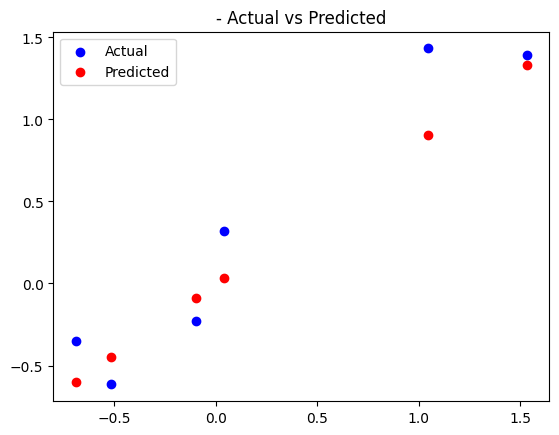

In [716]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred3, color='red', label='Predicted')
plt.legend()
plt.title("- Actual vs Predicted")
plt.show()

## 📊 R² Score (Coefficient of Determination)

### ✅ **Formula**

\[
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
\]

---

### 🧠 **Meaning of Each Term**

| Symbol | Meaning |
|--------|---------|
| \( y_i \)       | Actual value (true target) |
| \( \hat{y}_i \) | Predicted value (from the model) |
| \( \bar{y} \)   | Mean of actual values |
| \( \sum (y_i - \hat{y}_i)^2 \) | **Residual Sum of Squares (SSR)** – error of the model |
| \( \sum (y_i - \bar{y})^2 \)   | **Total Sum of Squares (SST)** – total variance in data |

---

### ✅ **What Does R² Score Represent?**

The R² score tells us **how much of the variation (variance) in the target variable `y` is explained by the model**.

| R² Value | Meaning |
|----------|---------|
| **1**    | Perfect fit — predictions are exactly correct |
| **0**    | Model explains no variance — just predicting the mean |
| **< 0**  | Model is worse than just predicting the mean (very poor model) |

---

### ❓ What Does “Variance Explained” Mean?

In statistics, **variance** is the amount by which data points differ from the mean.  
When we say "variance explained", we mean:

> How much of that difference (spread in the target variable `y`) can be **accounted for by the model**?

- High R² (e.g., 0.90) → **90% of the changes in `y`** are explained by the input `x`.
- The remaining 10% is likely due to noise, randomness, or missing variables.

---

### 🔍 Simple Intuition

Imagine you're predicting students' marks based on hours studied:

- If \( R^2 = 0.9 \), it means your model explains **90% of the variation in marks**.
- Only 10% of the variation is **unexplained** by the model — maybe due to motivation, sleep, or luck.


In [717]:
class UnivariateLinearRegressor:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.MSE_loss_history = []
        self.theta_history = []
        
    def MSE_loss(self, y_pred, y):
        m = y.shape[0]
        loss = (1 / (2 * m)) * np.sum((y_pred - y)**2)
        return loss
    
    def gradient_descent(self, X, y, y_pred, theta):
        m = y.shape[0]
        # Compute gradients first
        gradient_0 = np.sum(y_pred - y) / m
        gradient_1 = np.sum(np.dot((y_pred - y).T, X[:, 1])) / m

        # Update parameters
        theta[0] = theta[0] - self.learning_rate * gradient_0
        theta[1] = theta[1] - self.learning_rate * gradient_1
        
        return theta
    
    def fit(self, X: np.ndarray, y:np.ndarray) -> np.ndarray:
        """
        Reshape the input X and train the model

        Args:
            X (np.ndarray): Input feature matrix of dimension (n_samples, n_features)
            y (np.ndarray): Label matrix of dimension (n_samples, 1)

        Returns:
            np.ndarray: Parameter: theta matrix of dimension (n_features+1, 1)
        """
        # Add new dimension to X
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))

        # Initialize theta
        self.theta = np.zeros((X.shape[1], 1))
        
        # Training loop
        for i in range(self.n_iters):
            y_pred = np.dot(X, self.theta)
            # compute loss
            loss = self.MSE_loss(y_pred, y)
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)
            
            
            if i % 100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss}")
            
            # use gradient descent
            self.theta = self.gradient_descent(X, y, y_pred, self.theta)
        
        return self.theta
    
    def predict(self, X: np.ndarray, theta: np.ndarray) -> np.ndarray:
        # This function assumes that X has been normalized
        new_dimension = np.ones((X.shape[0], 1))
        X = np.hstack((new_dimension, X))
        predictions = np.dot(X, theta)
        
        return predictions

In [718]:

myModel = UnivariateLinearRegressor(learning_rate=0.01, n_iters=500)
theta = myModel.fit(X_train, y_train)

Iteration 0: MSE Loss = 0.5
Iteration 100: MSE Loss = 0.08234430966314454
Iteration 200: MSE Loss = 0.026386936069235006
Iteration 300: MSE Loss = 0.018889785349217498
Iteration 400: MSE Loss = 0.017885319533388414


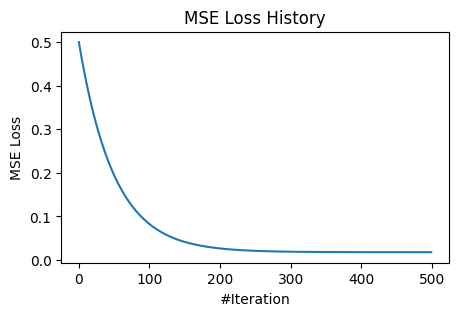

In [719]:

# Plotting Learning Curve
loss_history = myModel.MSE_loss_history
plt.figure(figsize=(5, 3))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("#Iteration")
plt.ylabel("MSE Loss")
plt.show()

In [720]:
y_pred4 = model1.predict(X_test)
y_pred4.shape

(6, 1)

In [721]:
r2 = r2_score(y_test, y_pred4)
r2

0.8973947623712942